<a href="https://colab.research.google.com/github/riyawakde16-art/Day28/blob/main/Day28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q.1

In [ ]:
import pandas as pd
import numpy as np
import string
import re
import nltk
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving train.txt to train.txt


In [ ]:

data = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text", "emotions"])


In [ ]:
print("\nFirst 10 Rows")
print(data.head(10))


First 10 Rows
                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love


In [ ]:
print("\nDataset Shape")
print(data.shape)


Dataset Shape
(16000, 2)


In [ ]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
text        0
emotions    0
dtype: int64


Q.2

In [ ]:
print("\nUnique Emotion Labels")
print(data["emotions"].unique())


Unique Emotion Labels
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']


In [ ]:
encoder = LabelEncoder()
data["emotion_encoded"] = encoder.fit_transform(data["emotions"])
mapping = dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)))
print("\nEmotion Mapping")
print(mapping)


Emotion Mapping
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [ ]:
print("\nDataset")
print(data.head())


Dataset
                                                text emotions  emotion_encoded
0                            i didnt feel humiliated  sadness                4
1  i can go from feeling so hopeless to so damned...  sadness                4
2   im grabbing a minute to post i feel greedy wrong    anger                0
3  i am ever feeling nostalgic about the fireplac...     love                3
4                               i am feeling grouchy    anger                0


Q.3

In [ ]:
print("\nBefore Lowercase")
print(data["text"].head())


Before Lowercase
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


In [ ]:
data["text_lower"] = data["text"].str.lower()
print("\nAfter Lowercase")
print(data["text_lower"].head())



After Lowercase
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_lower, dtype: object


In [ ]:
print("\nNote:")
print("Lowercasing reduces vocabulary size by treating words like Happy and happy as the same.")


Note:
Lowercasing reduces vocabulary size by treating words like Happy and happy as the same.


Q.4

In [ ]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))
data["no_punctuation"] = data["text_lower"].apply(remove_punctuation)
print("\nBefore Removing Punctuation")
print(data["text_lower"].head())



Before Removing Punctuation
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text_lower, dtype: object


In [20]:
print("\nAfter Removing Punctuation")
print(data["no_punctuation"].head())


After Removing Punctuation
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: no_punctuation, dtype: object


Q.5

In [21]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)
data["no_numbers"] = data["no_punctuation"].apply(remove_numbers)
print("\nAfter Removing Numbers")
print(data["no_numbers"].head())



After Removing Numbers
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: no_numbers, dtype: object


Q.6

In [22]:
def remove_emojis(text):
    return text.encode("ascii", "ignore").decode()
data["no_emojis"] = data["no_numbers"].apply(remove_emojis)
print("\nAfter Removing Emojis")
print(data["no_emojis"].head())


After Removing Emojis
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: no_emojis, dtype: object


Q.7

In [23]:
stop_words = set(stopwords.words("english"))
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
data["cleaned_text"] = data["no_emojis"].apply(remove_stopwords)
print("\nCleaned Samples")
print(data["cleaned_text"].head())



Cleaned Samples
0                                didnt feel humiliated
1    go feeling hopeless damned hopeful around some...
2            im grabbing minute post feel greedy wrong
3    ever feeling nostalgic fireplace know still pr...
4                                      feeling grouchy
Name: cleaned_text, dtype: object


Q.8

In [24]:
def clean_text(text):
    text = text.lower()
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_emojis(text)
    text = remove_stopwords(text)
    return text
data["cleaned_text"] = data["text"].apply(clean_text)
print("\nOriginal vs Cleaned")
print(data[["text", "cleaned_text"]].head(10))


Original vs Cleaned
                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   
5  ive been feeling a little burdened lately wasn...   
6  ive been taking or milligrams or times recomme...   
7  i feel as confused about life as a teenager or...   
8  i have been with petronas for years i feel tha...   
9                                i feel romantic too   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
5      ive feeling little burden

Q.9


Average Length
9.3530625

Minimum Length
1

Maximum Length
35


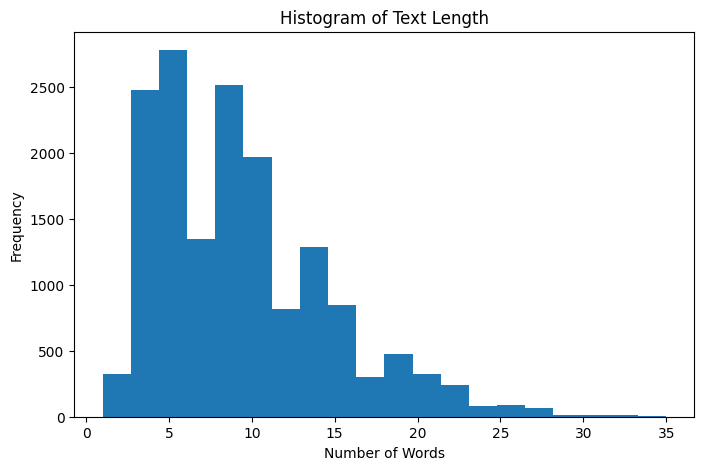


Observations:
1. Cleaning reduces sentence length.
2. Stopword removal decreases word count.
3. Dataset becomes suitable for NLP models.


In [25]:
data["text_length"] = data["cleaned_text"].apply(lambda x: len(x.split()))
print("\nAverage Length")
print(data["text_length"].mean())
print("\nMinimum Length")
print(data["text_length"].min())
print("\nMaximum Length")
print(data["text_length"].max())
plt.figure(figsize=(8,5))
plt.hist(data["text_length"], bins=20)
plt.title("Histogram of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print("\nObservations:")
print("1. Cleaning reduces sentence length.")
print("2. Stopword removal decreases word count.")
print("3. Dataset becomes suitable for NLP models.")

Q.10

1.

In [29]:
import pandas as pd
# Load the dataset
data = pd.read_csv(
    "train.txt",
    sep=";",
    names=["text", "emotions"])

In [27]:
# Display first 5 rows
print(data.head())

                                                text emotions
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [28]:
# Display dataset shape
print("Shape of Dataset:", data.shape)

Shape of Dataset: (16000, 2)


2.

In [32]:
from sklearn.preprocessing import LabelEncoder
# Create LabelEncoder object
encoder = LabelEncoder()
# Encode emotion labels
data["emotion_encoded"] = encoder.fit_transform(data["emotions"])
# Display mapping
mapping = dict(zip(encoder.classes_,
                   encoder.transform(encoder.classes_)))
print("Emotion Label Mapping:")
print(mapping)

Emotion Label Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [31]:
# Display dataset
print(data.head())

                                                text emotions  emotion_encoded
0                            i didnt feel humiliated  sadness                4
1  i can go from feeling so hopeless to so damned...  sadness                4
2   im grabbing a minute to post i feel greedy wrong    anger                0
3  i am ever feeling nostalgic about the fireplac...     love                3
4                               i am feeling grouchy    anger                0


3.

In [33]:
import string
import re
import nltk
from nltk.corpus import stopwords
# Download stopwords
nltk.download("stopwords")
# Load English stopwords
stop_words = set(stopwords.words("english"))
# Complete cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove emojis & special characters
    text = text.encode("ascii", "ignore").decode()
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
# Apply cleaning
data["cleaned_text"] = data["text"].apply(clean_text)
# Show original and cleaned text
print(data[["text", "cleaned_text"]].head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   
5  ive been feeling a little burdened lately wasn...   
6  ive been taking or milligrams or times recomme...   
7  i feel as confused about life as a teenager or...   
8  i have been with petronas for years i feel tha...   
9                                i feel romantic too   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
5      ive feeling little burdened lately wasnt sure 

4.

In [34]:
# Save cleaned dataset
data.to_csv("cleaned_emotions.csv", index=False)
print("Cleaned dataset saved successfully as cleaned_emotions.csv")

Cleaned dataset saved successfully as cleaned_emotions.csv


5.

In [35]:
# Display value counts
print("Emotion Counts:")
print(data["emotions"].value_counts())

Emotion Counts:
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
